

```
# 코드로 형식 지정됨
```

# 과제 1 - SVM 회귀


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_openml
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')


In [ ]:
import requests

try:
    url = "https://www.openml.org/"
    # 타임아웃 5초 설정
    response = requests.get(url, timeout=10)
    if response.status_code == 200:
        print("OpenML 서버에 정상적으로 접근했습니다.")
    else:
        print(f"OpenML 서버 접근에 실패했습니다. 상태 코드: {response.status_code}")
except requests.exceptions.RequestException as e:
    print("오류가 발생했습니다:", e)

오류가 발생했습니다: HTTPSConnectionPool(host='www.openml.org', port=443): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x7dd1817e53d0>, 'Connection to www.openml.org timed out. (connect timeout=10)'))


In [ ]:
# 데이터 로드
boston = fetch_openml(name='boston', version=1, as_frame=False)
X, y = boston.data, boston.target

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


KeyboardInterrupt: 

## openml 서버 접속 불가능, local 저장소에서 load

In [ ]:
import pandas as pd

# openml 서버 접속 불가능, local 저장소에서 load
df = pd.read_csv("Boston.csv")

X = df.drop(["medv"], axis=1)
y = df["medv"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# 모델 생성
svr = LinearSVR(epsilon = 10)

# 모델 훈련
svr.fit(X_train, y_train)


LinearSVR(epsilon=10)

In [ ]:
# 예측
y_pred = svr.predict(X_test)

# 성능 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 79.093927583305
R-squared: -0.07854694214246605


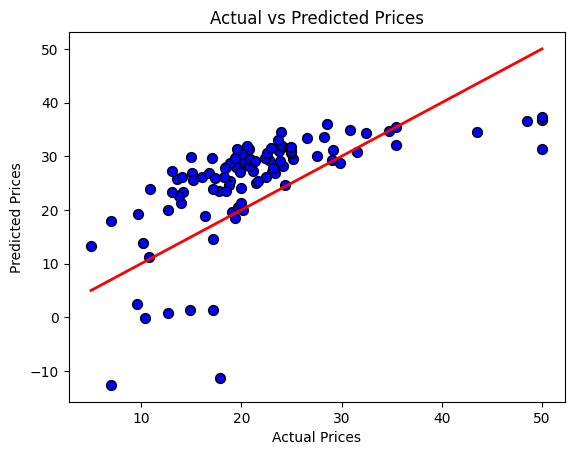

In [ ]:
# 일부 feature를 사용하여 2D로 시각화
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=50)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()


## 과제 1-1 : epsilon 값을 변경하면서 LinearSVR을 적합한 후, 결과를 확인하고 이유를 분석해주세요!

성능 평가 후 평가지표와 그래프를 사용해서 분석해주세요

In [ ]:
# 모델 생성
svr = LinearSVR() # Todo


# 모델 훈련
svr.fit(X_train, y_train)


LinearSVR()

[epsilon=0.0] MSE: 222.4977, R^2: -2.0340
[epsilon=1.0] MSE: 208.0201, R^2: -1.8366
[epsilon=5.0] MSE: 149.9635, R^2: -1.0449
[epsilon=10.0] MSE: 79.8572, R^2: -0.0890
[epsilon=15.0] MSE: 95.0133, R^2: -0.2956
[epsilon=20.0] MSE: 113.4692, R^2: -0.5473


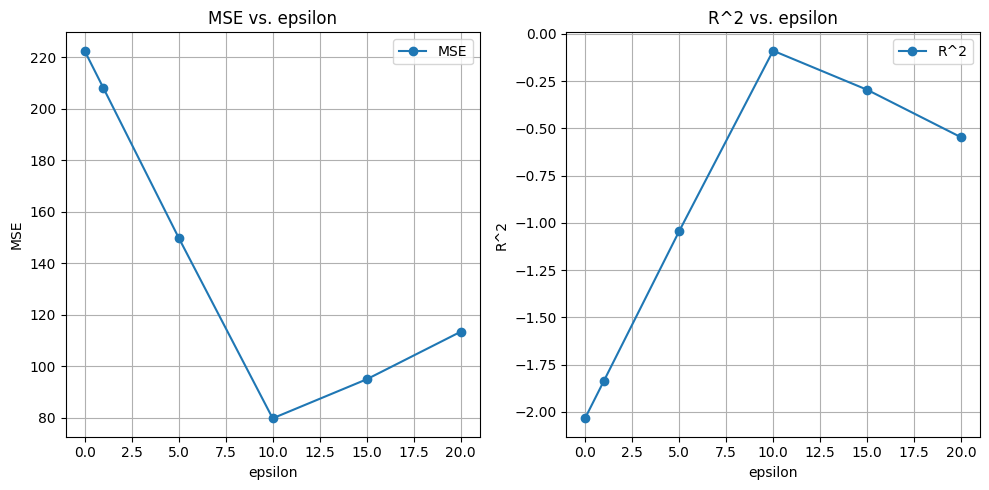

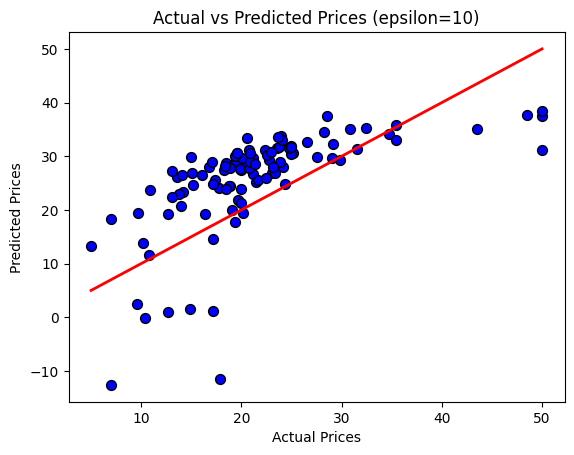

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import pandas as pd
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')


# openml 서버 접속 불가능, local 저장소에서 load
df = pd.read_csv("Boston.csv")

X = df.drop(["medv"], axis=1)
y = df["medv"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# epsilon 값을 바꿔가며 성능 비교
epsilon_values = [0.0, 1.0, 5.0, 10.0, 15.0, 20.0]  # Todo: 다양한 epsilon 값
mse_scores = []
r2_scores = []

for eps in epsilon_values:
    svr = LinearSVR(epsilon=eps, random_state=42)  # Todo

    svr.fit(X_train, y_train)  # Todo

    y_pred = svr.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mse_scores.append(mse)
    r2_scores.append(r2)

    # 결과 출력
    print(f"[epsilon={eps}] MSE: {mse:.4f}, R^2: {r2:.4f}")


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epsilon_values, mse_scores, marker='o', label='MSE')
plt.xlabel("epsilon")
plt.ylabel("MSE")
plt.title("MSE vs. epsilon")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epsilon_values, r2_scores, marker='o', label='R^2')
plt.xlabel("epsilon")
plt.ylabel("R^2")
plt.title("R^2 vs. epsilon")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# 최종 선택한 epsilon으로 시각화(Actual vs Predicted), epsilon=10 사용
svr_final = LinearSVR(epsilon=10, random_state=42)
svr_final.fit(X_train, y_train)
y_pred_final = svr_final.predict(X_test)

plt.scatter(y_test, y_pred_final, color='blue', edgecolor='k', s=50)
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color='red',
    linewidth=2
)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices (epsilon=10)')
plt.show()

# 과제 1-2 : SVM 분류

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')


In [ ]:
# 데이터 로드
iris = load_iris()
X, y = iris.data, iris.target

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 과제 1 - 2 trade-off 파라미터 C 값 설정

아래 수식처럼 C가 동작하는데, C가 작을수록 에러가 생겨도 가중치가 작기에 오버피팅을 막을 수 있음.

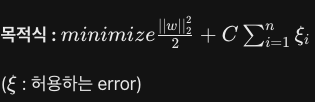


In [ ]:

# 다양한 trade-off 파라미터 C 값 설정
C_values = [0.01, 0.1, 1, 10, 100]  # Todo
train_accuracies = []
test_accuracies = []

for C in C_values:
    svc = LinearSVC(C=C)

    svc.fit(X_train, y_train)

    y_train_pred = svc.predict(X_train)
    y_test_pred = svc.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # 결과 저장
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"C={C}:")
    print(f"Training Accuracy: {train_acc}")
    print(f"Testing Accuracy: {test_acc}")
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")
    print("-" * 50)


C=0.01:
Training Accuracy: 0.8
Testing Accuracy: 0.8333333333333334
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.44      0.62         9
           2       0.69      1.00      0.81        11

    accuracy                           0.83        30
   macro avg       0.90      0.81      0.81        30
weighted avg       0.89      0.83      0.82        30

--------------------------------------------------
C=0.1:
Training Accuracy: 0.9666666666666667
Testing Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

------

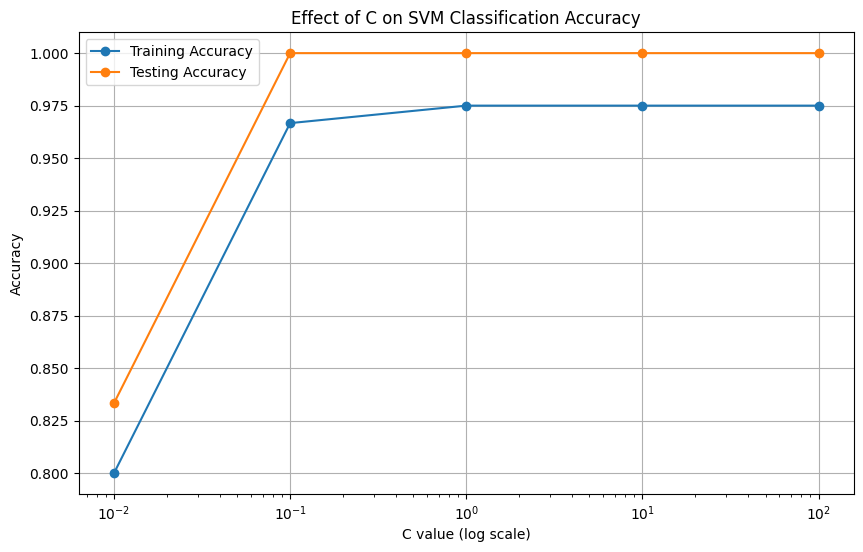

In [ ]:
# C 값에 따른 정확도 시각화
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(C_values, test_accuracies, marker='o', label='Testing Accuracy')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of C on SVM Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()
